In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.ndimage import uniform_filter1d

In [2]:
region_names_modifications = pd.read_excel(f'/Volumes/raid_126TB/H2B_GCaMP6s_new/Region_names_zbrain.xlsx',
                                           sheet_name='Sheet1', header=0, usecols='A,B,C,D,E')

In [3]:
root_path = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected'
compound = 'Tricaine'
reference_atlas = 'zbrain'

traces_dir = f'{root_path}/neurons/analysis/brain_region_traces/{compound}'

save_dir = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected/neurons/analysis/brain_region_activity'

In [4]:
file_list = sorted(glob.glob(f'{traces_dir}/fish*_{compound}_mean_traces_all_regions.csv'))
fish_dfs = [pd.read_csv(f, index_col=0) for f in file_list]   # each: time x region

all_regions = sorted(set().union(*[d.columns for d in fish_dfs]))
time_index = fish_dfs[0].index

# (n_fish, time, region)
stacked = np.stack([d.reindex(columns=all_regions).to_numpy() for d in fish_dfs])

mean_across   = np.nanmean(stacked, axis=0)   # time x region
median_across = np.nanmedian(stacked, axis=0)

# select mean (or median_across) and transpose to region x time
region_activity = pd.DataFrame(mean_across, index=time_index, columns=all_regions).T
region_activity.shape

(244, 1109)

In [5]:
time_steps = region_activity.columns.to_numpy()

minutes = np.round((len(time_steps) * 3.25) / 60)  # one frame every 3.25 seconds
x_ticklabels = np.arange(0, int(minutes) + 1, 10)
x_ticks = np.arange(0, len(time_steps) + 2, 185)   # 185 frames approx 10 min

# stimulus / phase boundaries (frames): habituation 0-185, stimulus1 185-370,
# recovery1 370-647, stimulus2 647-832, recovery2 832-1109
stim_lines = [185, 370, 647, 832]

In [7]:
cmap = sns.diverging_palette(255, 14, s=100, l=60, n=21, center='light', as_cmap=True)

vmax = 1.0
vmin = -vmax

cbar_ticks = [-vmax, 0, vmax]
cbar_ticklabels = [fr'$-{vmax:g}$', r'$0$', fr'$+{vmax:g}$']

**Sort regions by anatomical location**

In [6]:
region_activity = region_activity.copy()
region_activity['Region'] = region_activity.index

df_merge = pd.merge(region_activity, region_names_modifications,
                    left_on='Region', right_on='Original Names')
df_merge = df_merge[df_merge['Include']]

location_order = ['Telencephalon', 'Diencephalon', 'Mesencephalon', 'Rhombencephalon']
df_merge['Structure'] = pd.Categorical(df_merge['Structure'], categories=location_order, ordered=True)
df_merge = df_merge.sort_values(['Structure', 'Region'])

y_labels = df_merge['Short Names'].values
activity_values = df_merge[list(time_steps)].values
activity_values.shape

(244, 1109)

**Heatmap with region labels**

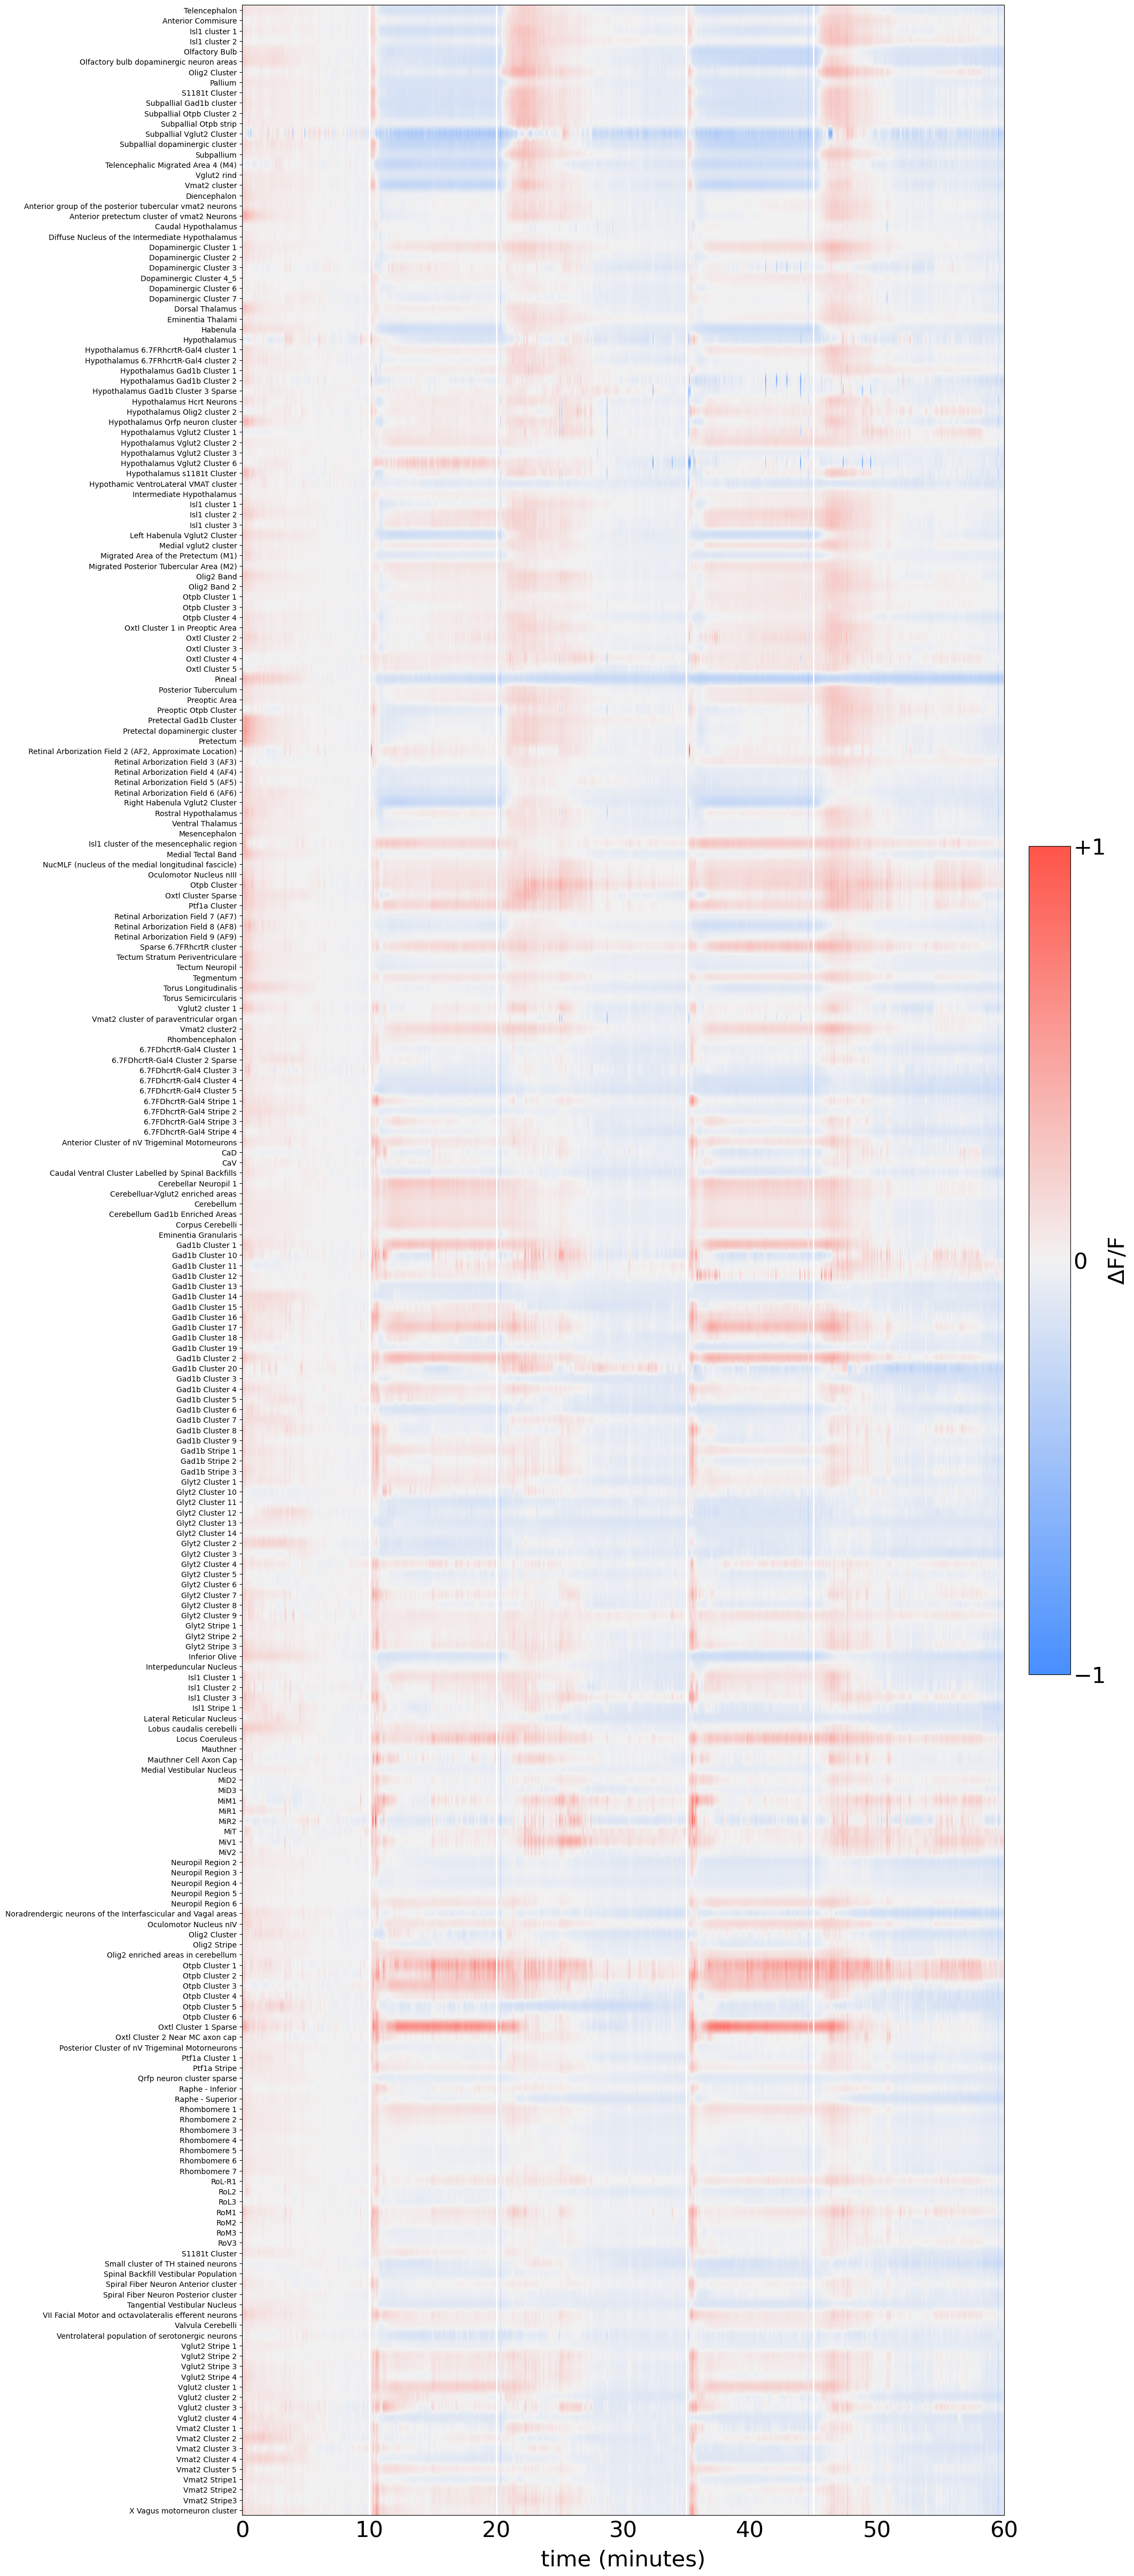

In [8]:
height = max(np.ceil(len(y_labels)/4), 6)

fig, ax = plt.subplots(figsize=(20, height))
img = ax.imshow(activity_values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)

for x in stim_lines:
    ax.axvline(x=x, color='white', linewidth=2)

ax.set_xlabel('time (minutes)', fontsize=30, labelpad=10)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize=30)
plt.tick_params(bottom=False)
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

cbar = fig.colorbar(img, fraction=0.05, pad=0.03)
cbar.ax.tick_params(size=0, labelsize=30)
cbar.ax.set_yticks(cbar_ticks)
cbar.ax.set_yticklabels(cbar_ticklabels)
cbar.set_label(r'$\Delta$F/F', fontsize=30)

path_to_save = f'{save_dir}/{compound}_brain_region_activity_from_neurons_heatmap.pdf'
fig.savefig(path_to_save, bbox_inches='tight', pad_inches=0.2)

**Heatmap with anatomical colorbar**

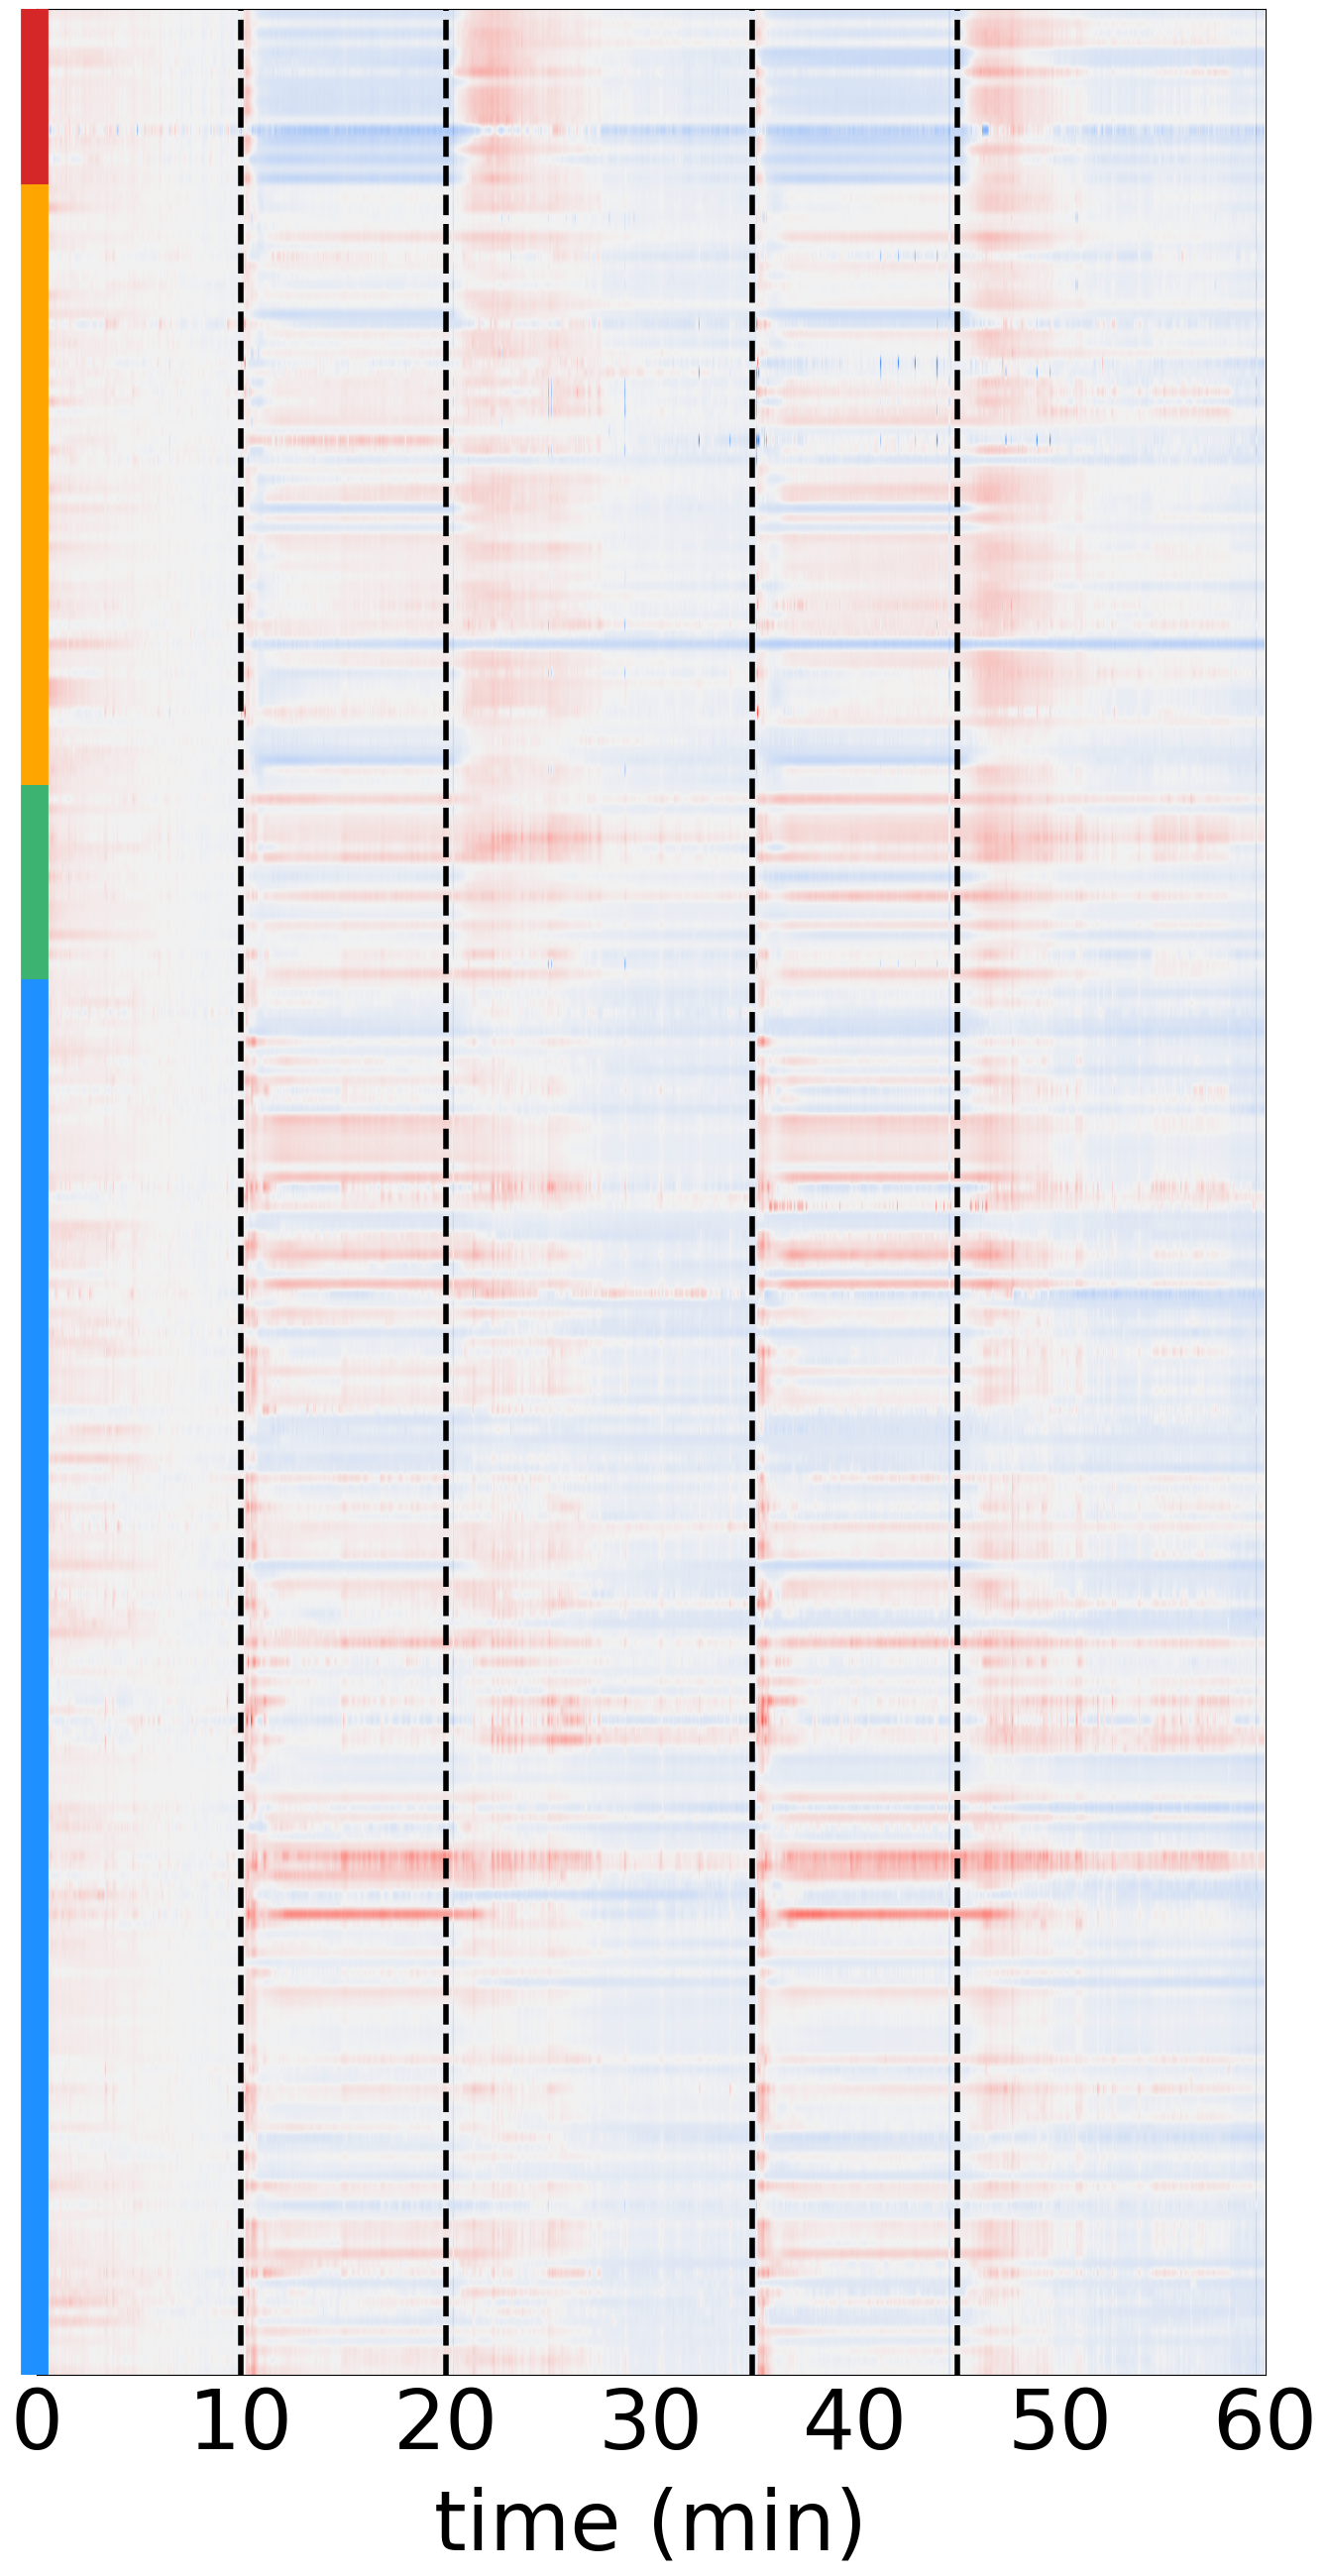

In [9]:
colors = {
    'Telencephalon': 'tab:red',
    'Diencephalon': 'orange',
    'Mesencephalon': 'mediumseagreen',
    'Rhombencephalon': 'dodgerblue',
}

height = max(np.ceil(len(y_labels)/8), 6)
width = round(height/2)

fig, ax = plt.subplots(figsize=(width, height))
img = ax.imshow(activity_values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)

for x in stim_lines:
    ax.axvline(x=x, color='black', linewidth=4, linestyle='--')

# colored segment per anatomical location drawn at the left edge
x_left_edge = -1
for loc, color in colors.items():
    idx = np.flatnonzero(df_merge['Structure'].to_numpy() == loc)
    if idx.size == 0:
        continue
    ax.vlines(x=x_left_edge, ymin=idx.min() - 0.5, ymax=idx.max() + 0.5,
              colors=color, linewidth=20, zorder=5, clip_on=False)

ax.set_xlabel('time (min)', fontsize=60, labelpad=15)
ax.set_xlim(0)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize=60)
plt.tick_params(bottom=False)
ax.set_yticks([])

#cbar = fig.colorbar(img, shrink=0.25, aspect=10, pad=0.03)
#cbar.ax.tick_params(size=0, labelsize=50, pad=15)
#cbar.ax.set_yticks(cbar_ticks)
#cbar.ax.set_yticklabels(cbar_ticklabels)
#cbar.set_label(r'$\Delta$F/F', fontsize=50)

path_to_save = f'{save_dir}/{compound}_brain_region_activity_from_neurons_heatmap_colorbar.pdf'
fig.savefig(path_to_save, bbox_inches='tight', pad_inches=0.2)
